#  High Dimensional Visualization

In [2]:
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_point, scale_x_log10, facet_grid, theme, stat_smooth, labs, element_text, theme_minimal
from plotnine.data import mtcars

In [6]:
mat = mtcars.iloc[1:10][['mpg', 'carb', 'hp', 'wt']].copy()
mat.index = mtcars.name[1:10]
mat.columns = ["Miles.per.gallon", "Carburetor", "Horsepower", "Weight"]
mat.head()

,Miles.per.gallon,Carburetor,Horsepower,Weight
name,,,,
Mazda RX4 Wag,21.0,4,110,2.875
Datsun 710,22.8,1,93,2.320
Hornet 4 Drive,21.4,1,110,3.215
Hornet Sportabout,18.7,2,175,3.440
Valiant,18.1,1,105,3.460


## Heat Maps

To draw heatmaps, we recommend using the Seaborn clustermap, which offers
convenient functionalities in particular for clustering (more later).

In [7]:
import seaborn as sns

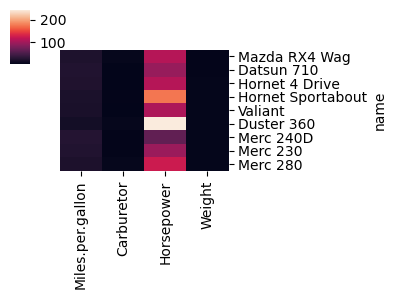

In [8]:
g = sns.clustermap(mat, row_cluster= False, col_cluster= False, figsize= (4,3))

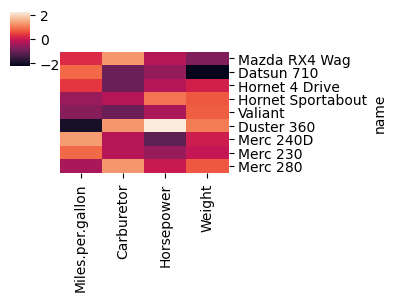

In [19]:
sns.clustermap(mat, row_cluster= False, col_cluster= False, z_score= 1, figsize= (4,3))

----------

## K-Means Algorithm

In [20]:
import sklearn

In [21]:
scaler = sklearn.preprocessing.StandardScaler()

In [ ]:
X = pd.DataFrame(scaler.fit_transform(mat), index = mat.index, columns= mat.columns)

In [25]:
k = 2
clust_km = sklearn.cluster.KMeans(n_clusters= k, n_init= 20)
clust_km.fit(X)

clust_km.labels_

array([1, 1, 1, 0, 0, 0, 1, 1, 0], dtype=int32)

We now update our heatmap with the results of the clustering using the row_colors
argument of clustermap() which generates row annotations on the left side of the
heatmap:

In [26]:
row_ann = pd.Series(['C'+str(s) for s in clust_km.labels_], index= mat.index)

unique_categories = np.unique(row_ann)

In [29]:
palette = sns.color_palette('husl', len(unique_categories))
palette


[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681)]

In [31]:
color_mapping = dict(zip(unique_categories, palette))
row_col = row_ann.map(color_mapping)

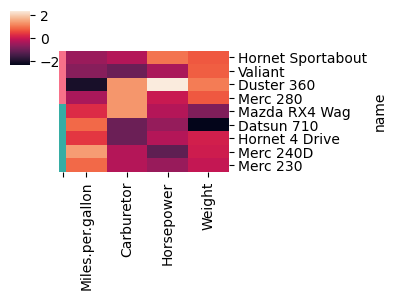

In [33]:
sns.clustermap(X.iloc[np.argsort(clust_km.labels_)], row_colors= row_col,
               row_cluster= False, col_cluster= False, figsize=(4,3))